# polaris_asap_poses.    

In [1]:
%load_ext autoreload
%autoreload 2    

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import os
from pathlib import Path
POLARIS_ASAP_POSES_HOME = Path(os.environ["POLARIS_ASAP_POSES_HOME"])
os.chdir(POLARIS_ASAP_POSES_HOME)    

In [3]:
from polaris_asap_poses.settings import get_settings
settings = get_settings()    

In [4]:
from polaris_asap_poses.logger import logger
logger.info("hello world")    

INFO    | 2025-03-14 02:03:56.323| __main__:2   | hello world


In [5]:
import polars as pl
import numpy as np
import polars.selectors as cs
from tqdm import tqdm
from pathlib import Path    

In [6]:
DATA_DIR_GNINA_OUT_16 = Path(POLARIS_ASAP_POSES_HOME) / "data/gnina-out-1-exhaustiveness-16"
DATA_DIR_GNINA_OUT_64 = Path(POLARIS_ASAP_POSES_HOME) / "data/gnina-out-2-exhaustiveness-64"

In [28]:
from polaris_asap_poses.dataprep import postprocess_gnina_out, compare_16_and_64, pick_best, submit
from polaris_asap_poses.io import DATA_DIR_RAW_REF_STRUCTURES

In [8]:
df_both = compare_16_and_64()

INFO    | 2025-03-14 02:04:12.117| polaris_asap_poses.dataprep:162 | Postprocessing gnina output data from /home/cbrown/workspace/polaris-asap-poses/data/gnina-out-1-exhaustiveness-16...
INFO    | 2025-03-14 02:04:12.121| polaris_asap_poses.dataprep:74  | Loading gnina output sdfs from /home/cbrown/workspace/polaris-asap-poses/data/gnina-out-1-exhaustiveness-16...
INFO    | 2025-03-14 02:04:12.147| polaris_asap_poses.util:19  | Shape: (195, 4), size: 5.449168384075165e-06 GB (0.005579948425292969 MB), columns: ['sdf: Object', 'test_or_train: String', 'ligand_id: Int32', 'protein_label: String'].
INFO    | 2025-03-14 02:04:12.150| polaris_asap_poses.dataprep:122 | Updating df_sdfs with mol data...
INFO    | 2025-03-14 02:04:12.152| polaris_asap_poses.util:19  | Shape: (195, 4), size: 5.449168384075165e-06 GB (0.005579948425292969 MB), columns: ['sdf: Object', 'test_or_train: String', 'ligand_id: Int32', 'protein_label: String'].
INFO    | 2025-03-14 02:04:13.596| polaris_asap_poses.data

In [9]:
df_both.head()

test_or_train,ligand_id,protein_label,rmsd,cnn_score_16,cnn_score_64,cnn_vs_16,cnn_vs_64,minimized_affinity_16,minimized_affinity_64,cnn_affinity_16,cnn_affinity_64,cnn_affinity_variance_16,cnn_affinity_variance_64,best_mol_16,best_mol_64,sdf_16,sdf_64
str,i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,object,object,object,object
"""test""",0,"""MERS-CoV-Mpro""",6.811208,0.337507,0.453284,2.455183,3.475743,-8.6392,-8.07719,7.274473,7.667908,0.073815,0.008787,<rdkit.Chem.rdchem.Mol object at 0x77c56bc109e0>,<rdkit.Chem.rdchem.Mol object at 0x77c5f0ac3bc0>,/home/cbrown/workspace/polaris-asap-poses/data/gnina-out-1-exhaustiveness-16/docked_test_0_MERS-CoV-Mpro.sdf,/home/cbrown/workspace/polaris-asap-poses/data/gnina-out-2-exhaustiveness-64/docked_test_0_MERS-CoV-Mpro.sdf
"""test""",1,"""MERS-CoV-Mpro""",7.898767,0.579482,0.517977,3.722855,3.365896,-7.94406,-7.51624,6.424454,6.498158,0.200137,0.04964,<rdkit.Chem.rdchem.Mol object at 0x77c56bc1a110>,<rdkit.Chem.rdchem.Mol object at 0x77c56bc88d60>,/home/cbrown/workspace/polaris-asap-poses/data/gnina-out-1-exhaustiveness-16/docked_test_1_MERS-CoV-Mpro.sdf,/home/cbrown/workspace/polaris-asap-poses/data/gnina-out-2-exhaustiveness-64/docked_test_1_MERS-CoV-Mpro.sdf
"""test""",2,"""SARS-CoV-2-Mpro""",1.202716,0.679494,0.423676,5.04221,2.973125,-7.8303,-7.9723,7.420537,7.017441,0.000247,0.054555,<rdkit.Chem.rdchem.Mol object at 0x77c56bc1a180>,<rdkit.Chem.rdchem.Mol object at 0x77c56bc88dd0>,/home/cbrown/workspace/polaris-asap-poses/data/gnina-out-1-exhaustiveness-16/docked_test_2_SARS-CoV-2-Mpro.sdf,/home/cbrown/workspace/polaris-asap-poses/data/gnina-out-2-exhaustiveness-64/docked_test_2_SARS-CoV-2-Mpro.sdf
"""test""",3,"""MERS-CoV-Mpro""",0.211834,0.693848,0.697877,4.907828,4.976865,-7.67781,-7.67297,7.073347,7.131432,0.277357,0.310589,<rdkit.Chem.rdchem.Mol object at 0x77c56bc1a1f0>,<rdkit.Chem.rdchem.Mol object at 0x77c56bc88e40>,/home/cbrown/workspace/polaris-asap-poses/data/gnina-out-1-exhaustiveness-16/docked_test_3_MERS-CoV-Mpro.sdf,/home/cbrown/workspace/polaris-asap-poses/data/gnina-out-2-exhaustiveness-64/docked_test_3_MERS-CoV-Mpro.sdf
"""test""",4,"""MERS-CoV-Mpro""",0.115752,0.285249,0.28406,2.099398,2.101311,-9.00829,-8.96363,7.35989,7.397422,0.234851,0.214009,<rdkit.Chem.rdchem.Mol object at 0x77c56bc1a260>,<rdkit.Chem.rdchem.Mol object at 0x77c56bc88eb0>,/home/cbrown/workspace/polaris-asap-poses/data/gnina-out-1-exhaustiveness-16/docked_test_4_MERS-CoV-Mpro.sdf,/home/cbrown/workspace/polaris-asap-poses/data/gnina-out-2-exhaustiveness-64/docked_test_4_MERS-CoV-Mpro.sdf


In [ ]:
#df_both.select(~cs.by_name(["best_mol_16", "best_mol_64", "sdf_16", "sdf_64"])).write_csv("summary_20250313_1148.csv")

In [10]:
df_both = pick_best(df_both)

INFO    | 2025-03-14 02:04:23.895| polaris_asap_poses.dataprep:243 | Picking best mol for submission...
INFO    | 2025-03-14 02:04:23.898| polaris_asap_poses.dataprep:256 | Processing ligand #0
INFO    | 2025-03-14 02:04:23.901| polaris_asap_poses.dataprep:256 | Processing ligand #1
INFO    | 2025-03-14 02:04:23.904| polaris_asap_poses.dataprep:256 | Processing ligand #2
INFO    | 2025-03-14 02:04:23.910| polaris_asap_poses.dataprep:256 | Processing ligand #3
INFO    | 2025-03-14 02:04:23.911| polaris_asap_poses.dataprep:274 | CNN score_diff is 0.004029273999999972, using cnn_vs instead
INFO    | 2025-03-14 02:04:23.915| polaris_asap_poses.dataprep:256 | Processing ligand #4
INFO    | 2025-03-14 02:04:23.917| polaris_asap_poses.dataprep:274 | CNN score_diff is 0.0011887550000000413, using cnn_vs instead
INFO    | 2025-03-14 02:04:23.919| polaris_asap_poses.dataprep:256 | Processing ligand #5
INFO    | 2025-03-14 02:04:23.921| polaris_asap_poses.dataprep:256 | Processing ligand #6
INFO 

In [11]:
df_both.head()

test_or_train,ligand_id,protein_label,rmsd,cnn_score_16,cnn_score_64,cnn_vs_16,cnn_vs_64,minimized_affinity_16,minimized_affinity_64,cnn_affinity_16,cnn_affinity_64,cnn_affinity_variance_16,cnn_affinity_variance_64,best_mol_16,best_mol_64,sdf_16,sdf_64,winner,winner_serialized,winner_str
str,i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,object,object,object,object,object,str,str
"""test""",0,"""MERS-CoV-Mpro""",6.811208,0.337507,0.453284,2.455183,3.475743,-8.6392,-8.07719,7.274473,7.667908,0.073815,0.008787,<rdkit.Chem.rdchem.Mol object at 0x77c56bc109e0>,<rdkit.Chem.rdchem.Mol object at 0x77c5f0ac3bc0>,/home/cbrown/workspace/polaris-asap-poses/data/gnina-out-1-exhaustiveness-16/docked_test_0_MERS-CoV-Mpro.sdf,/home/cbrown/workspace/polaris-asap-poses/data/gnina-out-2-exhaustiveness-64/docked_test_0_MERS-CoV-Mpro.sdf,<rdkit.Chem.rdchem.Mol object at 0x77c5f0ac3bc0>,"""776t3gAAAAAQAAAAAgAAAAAAAAApAAAALwAAAIABCAAoAAAAAwIGACgAAAADBAZAKAAAAAMEBkBoAAAAAwMBBkBoAAAAAwMBBkAoAAAAAwQRACAAAAABBkBoAAAAAwMBBkAoAAAAAwQGACAAAAAEBgBgAAAAAgIHACgAAAADAwYAKAAAAAMECAAoAAAAAwIHACgAAAADAwYAYAAAAAICBgBgAAAAAwEGQCgAAAADBAZAaAAAAAMDAQdAKAAAAAMDBkBoAAAAAwMBBkAoAAAAAwQGQGgAAAADAwEGQGgAAAADAwEGQGgAAAADAwEGQGgAAAADAwEGQCgAAAADBAYAYAAAAAICBkAoAAAAAwQHQCgAAAADAwdAKAAAAAMDBkBoAAAAAwMBCEAoAAAAAwIGAGAAAAACAgcAaAAAAAMCAQZAKAAAAAMEB0AoAAAAAwMGQGgAAAADAwEHQCgAAAADAwZAaAAAAAMDAQdAKAAAAAMDCwABKAIB…","""64"""
"""test""",1,"""MERS-CoV-Mpro""",7.898767,0.579482,0.517977,3.722855,3.365896,-7.94406,-7.51624,6.424454,6.498158,0.200137,0.04964,<rdkit.Chem.rdchem.Mol object at 0x77c56bc1a110>,<rdkit.Chem.rdchem.Mol object at 0x77c56bc88d60>,/home/cbrown/workspace/polaris-asap-poses/data/gnina-out-1-exhaustiveness-16/docked_test_1_MERS-CoV-Mpro.sdf,/home/cbrown/workspace/polaris-asap-poses/data/gnina-out-2-exhaustiveness-64/docked_test_1_MERS-CoV-Mpro.sdf,<rdkit.Chem.rdchem.Mol object at 0x77c56bc1a110>,"""776t3gAAAAAQAAAAAgAAAAAAAAAeAAAAIQAAAIABBwAoAAAAAwMGACgAAAADBAgAKAAAAAMCBkAoAAAAAwQGQGgAAAADAwEGQGgAAAADAwEGQCgAAAADBAZAaAAAAAMDAQZAaAAAAAMDAQYAYAAAAAEDCAAoAAAAAwIGAGAAAAACAgZAKAAAAAMEBkBoAAAAAwMBBkBoAAAAAwMBBkBoAAAAAwMBBkAoAAAAAwQRACAAAAABBkBoAAAAAwMBBgBgAAAAAgIGQCgAAAADBAZAaAAAAAMDAQdAKAAAAAMDBkBoAAAAAwMBBkAoAAAAAwQGQGgAAAADAwEGQGgAAAADAwEGQGgAAAADAwEGQGgAAAADAwEGQCgAAAADBAsJCgAKAyADBGgMBAVoDAUGaAwGACAACwALDAAMDWgMDQ5oDA4PaAwPEGgMEBEAEBJoDAABIAECKAIBEwATFAAUFWgMFRZoDBYXaAwXGGgMGBloDBkaaAwaG2gM…","""16"""
"""test""",2,"""SARS-CoV-2-Mpro""",1.202716,0.679494,0.423676,5.04221,2.973125,-7.8303,-7.9723,7.420537,7.017441,0.000247,0.054555,<rdkit.Chem.rdchem.Mol object at 0x77c56bc1a180>,<rdkit.Chem.rdchem.Mol object at 0x77c56bc88dd0>,/home/cbrown/workspace/polaris-asap-poses/data/gnina-out-1-exhaustiveness-16/docked_test_2_SARS-CoV-2-Mpro.sdf,/home/cbrown/workspace/polaris-asap-poses/data/gnina-out-2-exhaustiveness-64/docked_test_2_SARS-CoV-2-Mpro.sdf,<rdkit.Chem.rdchem.Mol object at 0x77c56bc1a180>,"""776t3gAAAAAQAAAAAgAAAAAAAAAoAAAALQAAAIABBwAoAAAAAwMGAGAAAAACAgYAIAAAAAQGACgAAAADBAgAKAAAAAMCBwAoAAAAAwMGAGAAAAACAgYAYAAAAAMBBkAoAAAAAwQGQGgAAAADAwEGQCgAAAADBBEAIAAAAAEGQGgAAAADAwEGQGgAAAADAwEGQCgAAAADBAYAKAAAAAMECAAoAAAAAwIGQCgAAAADBAZAaAAAAAMDAQdAKAAAAAMDBkBoAAAAAwMBBkAoAAAAAwQGQGgAAAADAwEGQGgAAAADAwEGQGgAAAADAwEGQGgAAAADAwEGQCgAAAADBAYAYAAAAAICBgBgAAAAAQMHAGgAAAADAgEGACgAAAADBAgAKAAAAAMCBgBgAAAAAgIHAGgAAAADAgEGQCgAAAADBAZAaAAAAAMDAQZAaAAAAAMDAQdAKAAAAAMDBkBoAAAAAwMBB0AoAAAAAwMLHB0AHR4gHh8oAh4b…","""16"""
"""test""",3,"""MERS-CoV-Mpro""",0.211834,0.693848,0.697877,4.907828,4.976865,-7.67781,-7.67297,7.073347,7.131432,0.277357,0.310589,<rdkit.Chem.rdchem.Mol object at 0x77c56bc1a1f0>,<rdkit.Chem.rdchem.Mol object at 0x77c56bc88e40>,/home/cbrown/workspace/polaris-asap-poses/data/gnina-out-1-exhaustiveness-16/docked_test_3_MERS-CoV-Mpro.sdf,/home/cbrown/workspace/polaris-asap-poses/data/gnina-out-2-exhaustiveness-64/docked_test_3_MERS-CoV-Mpro.sdf,<rdkit.Chem.rdchem.Mol object at 0x77c56bc88e40>,"""776t3gAAAAAQAAAAAgAAAAAAAAAhAAAAJQAAAIABBwAoAAAAAwMGAGAAAAACAgYAIAAAAAQGACg

In [37]:
#df_both.filter(pl.col("winner_str").eq("64"))

In [36]:
#df_both.filter(pl.col("winner_str").eq("16"))

In [22]:
def get_mols_and_rmsd_for_ligand(ligand_id: int, df_both: pl.DataFrame):
    """
    this made more sense before I had rmsd in the dataframe, but hey
    """
    from spyrmsd.molecule import Molecule
    from spyrmsd.rmsd import rmsdwrapper

    rdmol_16 = df_both.filter(pl.col("ligand_id").eq(ligand_id))["best_mol_16"].item()
    rdmol_64 = df_both.filter(pl.col("ligand_id").eq(ligand_id))["best_mol_64"].item()

    mol_16 = Molecule.from_rdkit(rdmol_16)
    mol_64 = Molecule.from_rdkit(rdmol_64)

    rmsd = rmsdwrapper(mol_16, mol_64)
    return rdmol_16, rdmol_64, rmsd

In [23]:
mol_16, mol_64, rmsd = get_mols_and_rmsd_for_ligand(165, df_both)

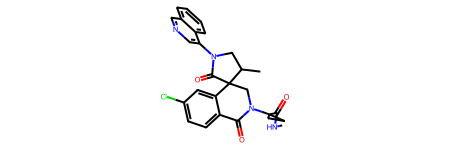

In [24]:
mol_16

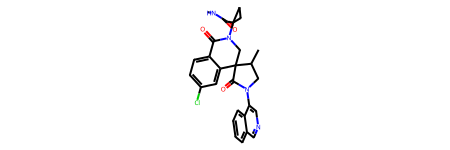

In [25]:
mol_64

In [26]:
rmsd[0]

np.float64(7.680924592651591)

In [ ]:
# Histogram - cnn_score

import matplotlib.pyplot as plt
import seaborn as sns
df = df_both

sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot histogram for cnn_score_16
plt.hist(df["cnn_score_16"], bins=20, alpha=0.5, label="Exhaustiveness 16", color="blue", density=True)

# Plot histogram for cnn_score_64
plt.hist(df["cnn_score_64"], bins=20, alpha=0.5, label="Exhaustiveness 64", color="orange", density=True)

# Add labels and title
plt.xlabel("CNN Score", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title("Histogram of CNN Scores for Exhaustiveness 16 vs. 64", fontsize=14)
plt.legend()

# Show the plot
plt.savefig("doc/cnn_score_histogram.png")
plt.show()

In [ ]:
# Histogram - cnn_vs
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot histogram for cnn_vs_16
plt.hist(df["cnn_vs_16"], bins=20, alpha=0.5, label="Exhaustiveness 16", color="blue", density=True)

# Plot histogram for cnn_vs_64
plt.hist(df["cnn_vs_64"], bins=20, alpha=0.5, label="Exhaustiveness 64", color="orange", density=True)

# Add labels and title
plt.xlabel("CNN VS", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title("Histogram of CNN VS for Exhaustiveness 16 vs. 64", fontsize=14)
plt.legend()

# Show the plot
plt.savefig("doc/cnn_vs_histogram.png")
plt.show()

In [ ]:
# Save winners

In [15]:
from rdkit import Chem
with Chem.SDWriter("submitted_poses.sdf") as w:
    for i in df_both["winner"].to_list():
        w.write(mol=i)

In [17]:
df_both_sars = df_both.filter(pl.col("protein_label").eq("SARS-CoV-2-Mpro"))
df_both_mers = df_both.filter(pl.col("protein_label").eq("MERS-CoV-Mpro"))

In [20]:
with Chem.SDWriter("submitted_poses.sars.sdf") as w:
    for i in df_both_sars["winner"].to_list():
        w.write(mol=i)

In [21]:
with Chem.SDWriter("submitted_poses.mers.sdf") as w:
    for i in df_both_mers["winner"].to_list():
        w.write(mol=i)

In [31]:
# mers
import py3Dmol
v = py3Dmol.view()
v.addModel(open(DATA_DIR_RAW_REF_STRUCTURES / "MERS-CoV-Mpro" / "protein.pdb").read())
v.setStyle({'cartoon':{},'stick':{'radius':.1}})
v.addModel(open(DATA_DIR_RAW_REF_STRUCTURES  / "MERS-CoV-Mpro" / "ligand.sdf").read())
v.setStyle({'model':1},{'stick':{'colorscheme':'dimgrayCarbon','radius':.125}})
v.addModelsAsFrames(open("submitted_poses.mers.sdf").read())
v.setStyle({'model':2},{'stick':{'colorscheme':'greenCarbon'}})
v.zoomTo({'model':1})
v.rotate(90)
v.animate({'interval':1000})

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [35]:
# sars
import py3Dmol
v = py3Dmol.view()
v.addModel(open(DATA_DIR_RAW_REF_STRUCTURES / "SARS-CoV-2-Mpro" / "protein.pdb").read())
v.setStyle({'cartoon':{},'stick':{'radius':.1}})
v.addModel(open(DATA_DIR_RAW_REF_STRUCTURES  / "SARS-CoV-2-Mpro" / "ligand.sdf").read())
v.setStyle({'model':1},{'stick':{'colorscheme':'dimgrayCarbon','radius':.125}})
v.addModelsAsFrames(open("submitted_poses.sars.sdf").read())
v.setStyle({'model':2},{'stick':{'colorscheme':'greenCarbon'}})
v.zoomTo({'model':1})
v.rotate(90)
v.animate({'interval':1000})

3Dmol.js failed to load for some reason. Please check your browser console for error messages.